In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import glob
import os

In [2]:
files = {
    "AlphaFold2": "./merged_with_class/merged_af2.csv",
    "Boltz-2": "./merged_with_class/merged_boltz.csv",
    "Chai-1": "./merged_with_class/merged_chai1.csv",
    "HelixFold3": "./merged_with_class/merged_helixfold3.csv",
    "OpenFold3": "./merged_with_class/merged_of3.csv",
    "Protenix": "./merged_with_class/merged_protenix.csv"
}

dfs = []

for model, filename in files.items():
    df = pd.read_csv(filename)
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

<function matplotlib.pyplot.show(close=None, block=None)>

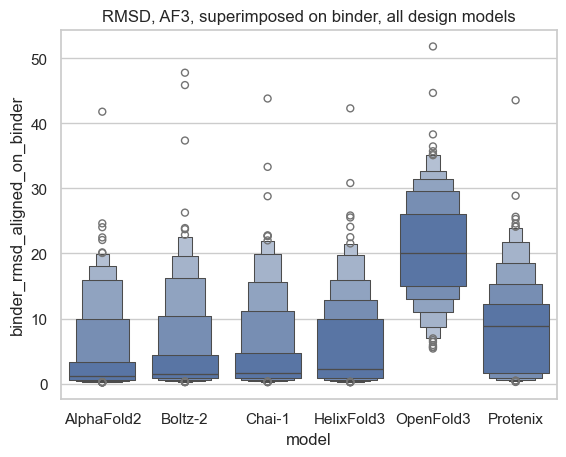

In [22]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_all,
    x="model",
    y="binder_rmsd_aligned_on_binder",
    width_method="linear",
)
plt.title("RMSD, AF3, superimposed on binder, all design models")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

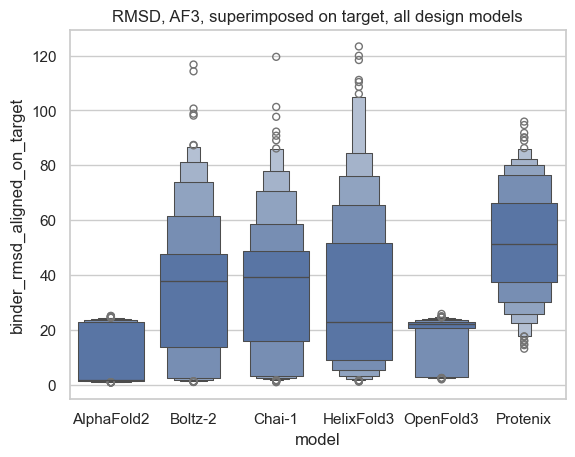

In [21]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_all,
    x="model",
    y="binder_rmsd_aligned_on_target",
    width_method="linear",
)
plt.title("RMSD, AF3, superimposed on target, all design models")
plt.show

In [10]:
def load_selected_design_classes(files):
    """Load CSVs and keep only rows where design_class is Peptide or Miniprotein."""

    dfs = []
    desired = {"Peptide", "Miniprotein"}

    for model, filename in files.items():
        df = pd.read_csv(filename)

        # filter here
        df = df[df["design_class"].isin(desired)]

        df["model"] = model
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df_filtered = load_selected_design_classes(files)

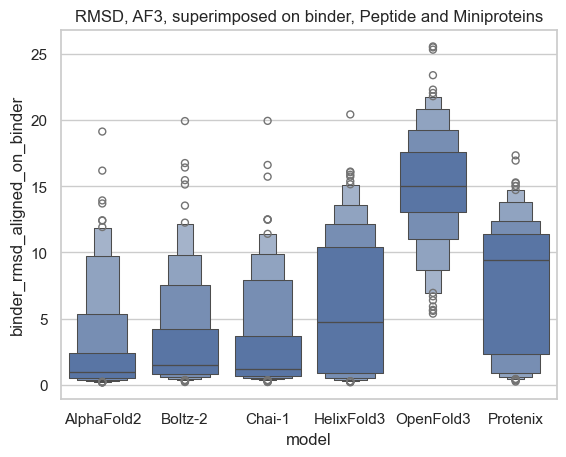

In [20]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_filtered,
    x="model",
    y="binder_rmsd_aligned_on_binder",
    width_method="linear"
)
plt.title("RMSD, AF3, superimposed on binder, Peptide and Miniproteins")
plt.show()


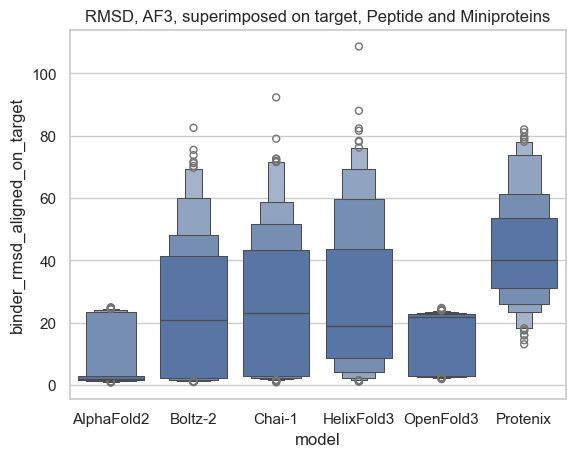

In [19]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_filtered,
    x="model",
    y="binder_rmsd_aligned_on_target",
    width_method="linear"
)
plt.title("RMSD, AF3, superimposed on target, Peptide and Miniproteins")
plt.show()

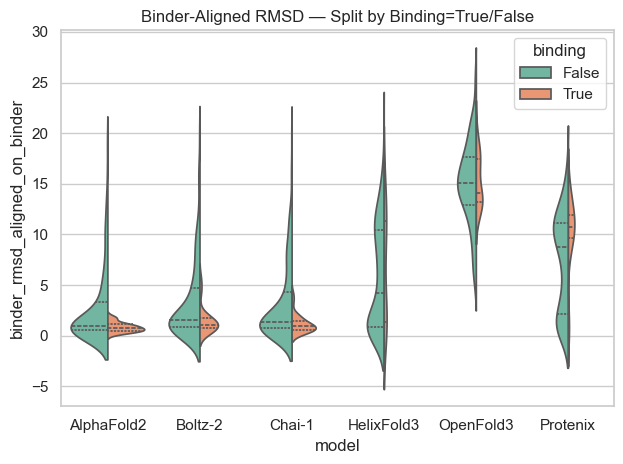

In [23]:

sns.violinplot(
    data=df_filtered,          # your filtered DF (Peptide + Miniprotein)
    x="model",
    y="binder_rmsd_aligned_on_binder",
    hue="binding",             # split by True/False
    split=True,                # the magic option
    inner="quartile",          # shows quartile lines
    palette="Set2"
)

plt.title("Binder-Aligned RMSD — Split by Binding=True/False")
plt.tight_layout()
plt.show()


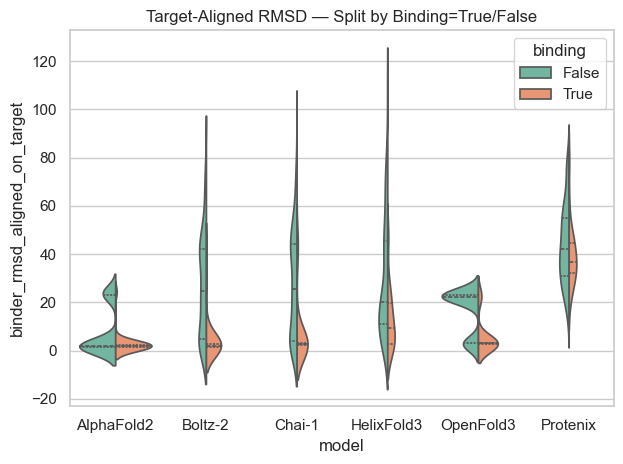

In [25]:

sns.violinplot(
    data=df_filtered,          # your filtered DF (Peptide + Miniprotein)
    x="model",
    y="binder_rmsd_aligned_on_target",
    hue="binding",             # split by True/False
    split=True,                # the magic option
    inner="quartile",          # shows quartile lines
    palette="Set2"
)

plt.title("Target-Aligned RMSD — Split by Binding=True/False")
plt.tight_layout()
plt.show()


In [32]:
rmsd_col = "binder_rmsd_aligned_on_binder"

order = (
    df_filtered.groupby("model")[rmsd_col]
    .median()
    .sort_values(ascending=True)
    .index
)

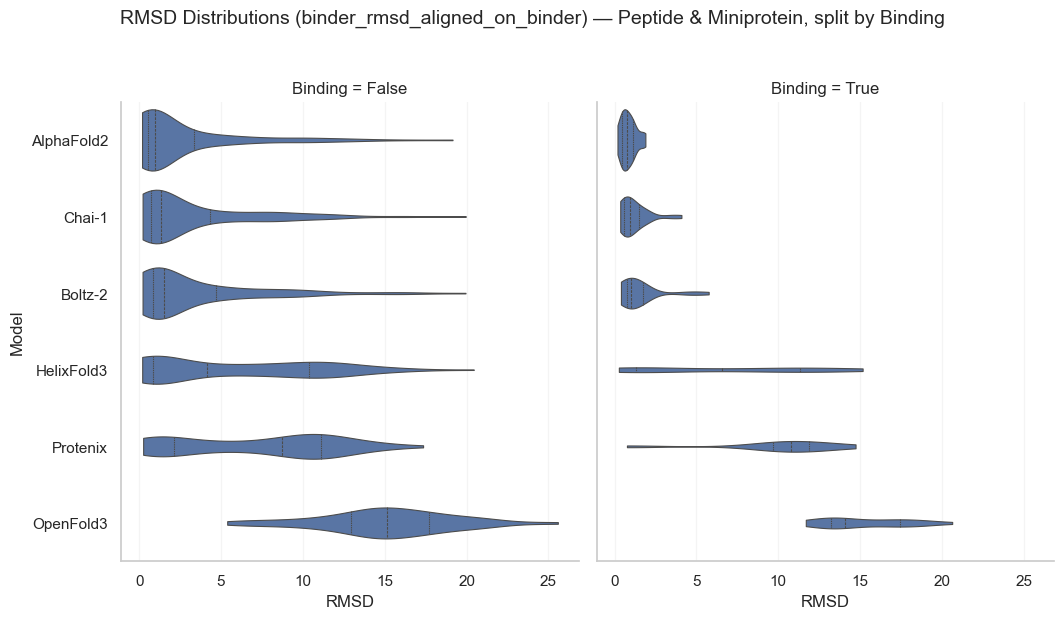

In [37]:
g = sns.FacetGrid(
    df_filtered,
    col="binding",
    sharey=True,
    height=6,
    aspect=0.9
)

# Violin per model (horizontal)
g.map_dataframe(
    sns.violinplot,
    x=rmsd_col, y="model",
    order=order,
    orient="h",
    inner="quartile",        # show quartile lines
    cut=0,                   # trim tails to data range
    linewidth=0.8,
)

# Titles & labels
g.set_axis_labels("RMSD", "Model")
g.set_titles(col_template="Binding = {col_name}")
for ax in g.axes.flat:
    ax.grid(True, axis="x", alpha=0.2)
    ax.set_ylabel("Model")  # ensure present on both facets

plt.suptitle(f"RMSD Distributions ({rmsd_col}) — Peptide & Miniprotein, split by Binding", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()
